In [ ]:
!pip install skimpy mlflow lightgbm xgboost catboost dowhy causalml polars optuna imblearn scikit-posthocs shap

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import skimpy as sk
import plotly.express as px
from imblearn.over_sampling import SMOTE
import os
import shutil
import mlflow
import mlflow.sklearn
from statsmodels.stats.outliers_influence import variance_inflation_factor
from warnings import filterwarnings; filterwarnings("ignore")
from itertools import combinations
from scipy.stats import (
    wilcoxon,
    friedmanchisquare,
    bootstrap
)
from statsmodels.stats.multitest import multipletests
import scikit_posthocs as sp
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.base import clone
import shap
import scipy.stats as stats # Added this line



from sklearn.preprocessing import *
from sklearn.impute import SimpleImputer
from sklearn.model_selection import *
from sklearn.metrics import *
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, clone, TransformerMixin
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import joblib

## Engineering Rigour:
- Curse of Dimensionality: The Law states that Matrix sparsity should be considered as ML/DL models decision boundaries lack the searching powers that other models have
- No Free Lunch theorem: This law states that no ML/DL Model is superior against one another. For Example, if an ML model that is applied to a material science domain should there be execeptions and constrained to it-- there is an observed decreased performance if other models are applied--there is no bias behind such decisions
- Law of Statistical Triangulation: States that confirmation between two or more test confirms the robustness of the model
- Paretto Frontier Problem: The model chosen should be based on the goal that the scientist/engineer that is choosing

## Causal Assumption:
- Building_id + meter -> meter_reading
- meter -> meter_reading
-physics based

In [ ]:
train = pd.read_csv("/content/drive/MyDrive/data_energy/train_data_preprocessed.csv").sort_values(
    ["building_id", "meter", "timestamp"]
)
test = pd.read_csv("/content/drive/MyDrive/data_energy/test_data_preprocessed.csv").sort_values(
    ["building_id", "meter", "timestamp"]
)

In [ ]:
train.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'air_temperature', 'cloud_coverage', 'dew_temperature',
       'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
       'wind_speed'],
      dtype='object')

In [ ]:
train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp'] = pd.to_datetime(test['timestamp'])

train = train.set_index('timestamp')
test = test.set_index('timestamp')

In [ ]:
train

,building_id,meter,meter_reading,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
timestamp,,,,,,,,,,,
2016-01-01 00:00:00,0,0,0.000,0,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
2016-01-01 00:00:00,0,0,0.000,1,3.8,6.0,2.4,-1.0,1020.9,240.0,3.1
2016-01-01 00:00:00,0,0,0.000,2,15.6,6.0,-5.6,-1.0,1015.3,270.0,3.6
2016-01-01 00:00:00,0,0,0.000,3,10.0,8.0,2.2,-1.0,1021.1,350.0,4.1
2016-01-01 00:00:00,0,0,0.000,7,-1.8,6.0,-3.2,-1.0,1016.0,280.0,1.5
...,...,...,...,...,...,...,...,...,...,...,...
2016-01-03 11:00:00,1448,0,3.125,10,-7.8,0.0,-13.3,0.0,1028.7,300.0,1.5
2016-01-03 11:00:00,1448,0,3.125,11,-1.1,5.0,-2.0,7.0,1001.6,210.0,3.1
2016-01-03 11:00:00,1448,0,3.125,12,8.9,5.0,6.0,0.0,980.2,210.0,4.0


In [ ]:
sk.skim(test)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                 Data Types                                                                │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                         │
│ ┃ Dataframe         ┃ Values  ┃ ┃ Column Type ┃ Count ┃                                                         │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                         │
│ │ Number of rows    │ 4388029 │ │ float64     │ 7     │                                                         │
│ │ Number of columns │ 11      │ │ int64       │ 4     │                                                         │
│ └───────────────────┴─────────┘ └─────────────┴───────┘                                                         │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column               ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0    ┃ p25   ┃ p50    ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ row_id               │   0 │     0 │  138400 │   79810 │     0 │ 69390 │ 138300 │ 207000 │ 277200 │ ██████ │  │
│ │ building_id          │   0 │     0 │   52.92 │   30.89 │     0 │    27 │     53 │     80 │    104 │ ▇▇▆▆▇█ │  │
│ │ meter                │   0 │     0 │   0.186 │  0.3891 │     0 │     0 │      0 │      0 │      1 │ █    ▂ │  │
│ │ site_id              │   0 │     0 │   7.479 │   4.622 │     0 │     3 │      7 │     12 │     15 │ █▅█▅██ │  │
│ │ air_temperature      │   0 │     0 │   7.206 │   9.829 │   -25 │     1 │    7.2 │   13.9 │   34.4 │  ▂▆█▄▁ │  │
│ │ cloud_coverage       │   0 │     0 │   2.545 │   2.844 │     0 │     0 │      2 │      4 │      9 │ █▃▃ ▂▂ │  │
│ │ dew_temperature      │   0 │     0 │   1.203 │    9.46 │ -28.2 │    -5 │      2 │      8 │   21.7 │  ▂▄█▆▂ │  │
│ │ precip_depth_1_hr    │   0 │     0 │  0.6233 │   4.369 │    -1 │     0 │      0 │      0 │    163 │   █    │  │
│ │ sea_level_pressure   │   0 │     0 │    1017 │   9.845 │ 973.7 │  1011 │   1017 │   1024 │   1050 │  ▁▄█▃  │  │
│ │ wind_direction       │   0 │     0 │   184.5 │   109.1 │     0 │    90 │    190 │    280 │    360 │ ▆▅▆▆█▇ │  │
│ │ wind_speed           │   0 │     0 │   3.887 │   2.573 │     0 │   2.1 │    3.6 │    5.1 │     23 │  █▅▁   │  │
│ └──────────────────────┴─────┴───────┴─────────┴─────────┴───────┴───────┴────────┴────────┴────────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

## EDA

In [ ]:
os.makedirs("Visualizations", exist_ok=True)

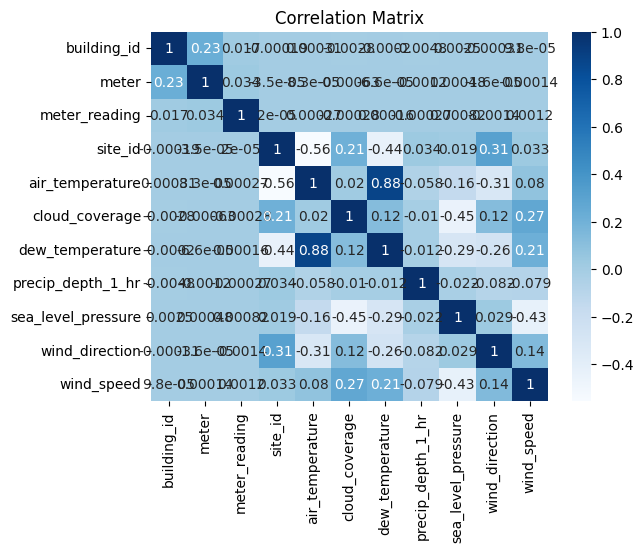

<Figure size 5000x2500 with 0 Axes>

In [ ]:
corr = train.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="Blues")

plt.title("Correlation Matrix")
plt.figure(figsize=(50, 25))
plt.savefig("Visualizations/Correlation.png")
plt.show()

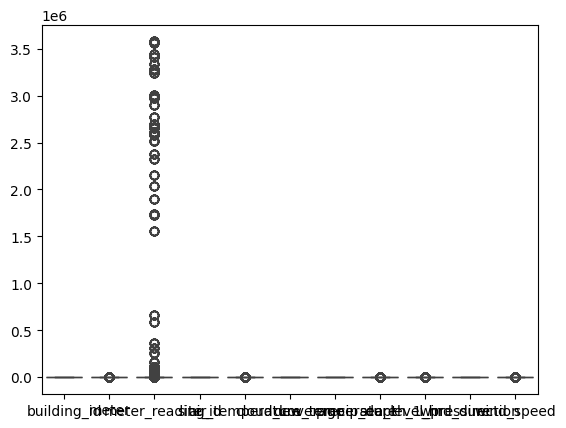

<Figure size 5000x2500 with 0 Axes>

In [ ]:
#Outlier detecttion
sns.boxplot(train)
plt.figure(figsize=(50, 25))
plt.savefig("Visualizations/Outlier.png")
plt.show()

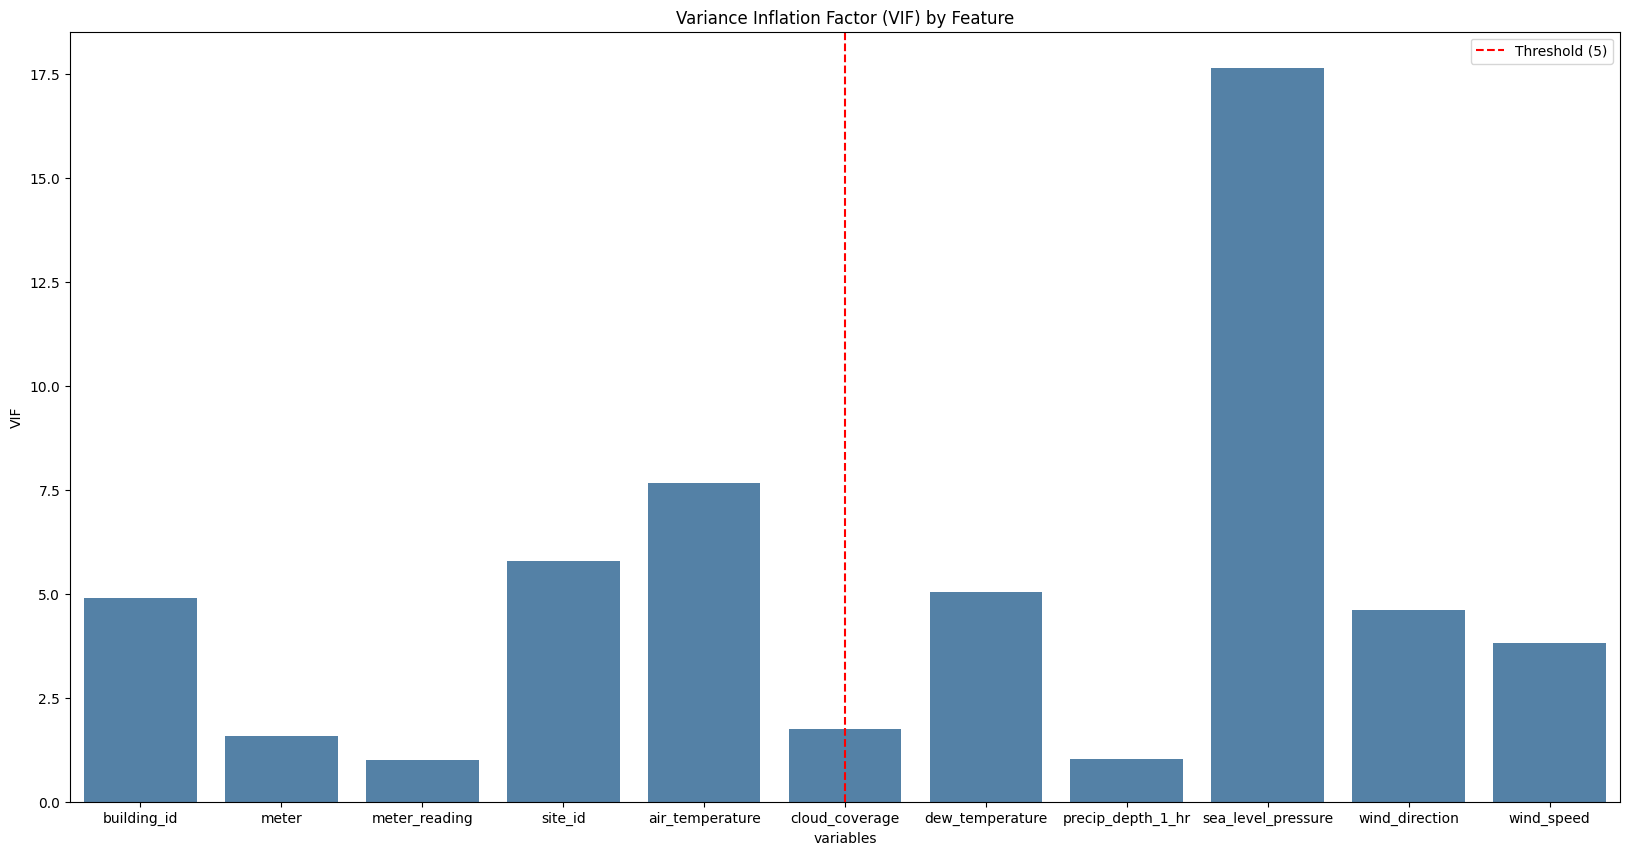

In [ ]:
#Variance Inflation Factor
vif = pd.DataFrame({
    "variables": train.select_dtypes(include=np.number).columns,
    "VIF": [variance_inflation_factor(train.select_dtypes(include=np.number).values, i) for i in range(train.select_dtypes(include=np.number).shape[1])]
})


plt.figure(figsize=(20, 10))
sns.barplot(x="variables", y="VIF", data=vif, color="steelblue")
plt.axvline(5, color='red', linestyle='--', label='Threshold (5)')
plt.title("Variance Inflation Factor (VIF) by Feature")
plt.legend()
plt.show()

## Feature Engineering

In [ ]:
def feature_engineer_energy(df, train_stats=None, is_train=True):
    df = df.copy()

    df = df.sort_values(["building_id", "meter", "timestamp"])

    group_cols = ["building_id", "meter"]


    temp = df["air_temperature"]

    df["cooling_degree"] = np.maximum(temp - 18, 0)
    df["heating_degree"] = np.maximum(18 - temp, 0)

    df["temp_dew_gap"] = df["air_temperature"] - df["dew_temperature"]

    df["humidity_proxy"] = df["dew_temperature"] / (df["air_temperature"] + 1e-6)

    df["feels_like_temp"] = df["air_temperature"] - 0.7 * df["wind_speed"]


    df["is_raining"] = (df["precip_depth_1_hr"] > 0).astype(int)

    df["weather_stress"] = (
        df["wind_speed"] +
        df["cloud_coverage"] +
        df["is_raining"]
    )

    df["storm_intensity"] = (
        df["wind_speed"] ** 2 +
        df["cloud_coverage"]
    )

    df["wind_x"] = np.sin(np.deg2rad(df["wind_direction"]))
    df["wind_y"] = np.cos(np.deg2rad(df["wind_direction"]))
    df["wind_energy"] = df["wind_speed"] ** 2

    if train_stats is not None:
        pressure_mean = train_stats["pressure_mean"]
    else:
        pressure_mean = df["sea_level_pressure"].mean()

    df["pressure_anomaly"] = df["sea_level_pressure"] - pressure_mean


    df["sunlight_proxy"] = 8 - df["cloud_coverage"]


    df["thermal_load_proxy"] = (
        df["cooling_degree"] + df["heating_degree"]
    )

    df["environmental_load_index"] = (
        df["weather_stress"] + np.abs(df["pressure_anomaly"])
    )


    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)

    return df

In [ ]:
train_stats = {
    "pressure_mean": train["sea_level_pressure"].mean()
}

train = feature_engineer_energy(
    train,
    train_stats=train_stats,
    is_train=True
)

test = feature_engineer_energy(
    test,
    train_stats=train_stats,
    is_train=False
)

In [ ]:
train["meter_reading"] = np.log1p(train["meter_reading"])

In [ ]:
set(train.columns).difference(set(test.columns))

{'meter_reading'}

In [ ]:
train

,building_id,meter,meter_reading,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,...,is_raining,weather_stress,storm_intensity,wind_x,wind_y,wind_energy,pressure_anomaly,sunlight_proxy,thermal_load_proxy,environmental_load_index
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,0,0,0.000000,0,25.0,6.0,20.0,-1.0,1019.7,0.0,...,0,6.0,6.00,0.000000,1.000000e+00,0.00,2.531813,2.0,7.0,8.531813
2016-01-01 00:00:00,0,0,0.000000,1,3.8,6.0,2.4,-1.0,1020.9,240.0,...,0,9.1,15.61,-0.866025,-5.000000e-01,9.61,3.731813,2.0,14.2,12.831813
2016-01-01 00:00:00,0,0,0.000000,2,15.6,6.0,-5.6,-1.0,1015.3,270.0,...,0,9.6,18.96,-1.000000,-1.836970e-16,12.96,-1.868187,2.0,2.4,11.468187
2016-01-01 00:00:00,0,0,0.000000,3,10.0,8.0,2.2,-1.0,1021.1,350.0,...,0,12.1,24.81,-0.173648,9.848078e-01,16.81,3.931813,0.0,8.0,16.031813
2016-01-01 00:00:00,0,0,0.000000,7,-1.8,6.0,-3.2,-1.0,1016.0,280.0,...,0,7.5,8.25,-0.984808,1.736482e-01,2.25,-1.168187,2.0,19.8,8.668187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-01-03 11:00:00,1448,0,1.417066,10,-7.8,0.0,-13.3,0.0,1028.7,300.0,...,0,1.5,2.25,-0.866025,5.000000e-01,2.25,11.531813,8.0,25.8,13.031813
2016-01-03 11:00:00,1448,0,1.417066,11,-1.1,5.0,-2.0,7.0,1001.6,210.0,...,1,9.1,14.61,-0.500000,-8.660254e-01,9.61,-15.568187,3.0,19.1,24.668187
2016-01-03 11:00:00,1448,0,1.417066,12,8.9,5.0,6.0,0.0,980.2,210.0,...,0,9.0,21.00,-0.500000,-8.660254e-01,16.00,-36.968187,3.0,9.1,45.968187


In [ ]:
test

,row_id,building_id,meter,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,...,is_raining,weather_stress,storm_intensity,wind_x,wind_y,wind_energy,pressure_anomaly,sunlight_proxy,thermal_load_proxy,environmental_load_index
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,0,0,0,0,17.8,4.0,11.7,5.0,1021.4,100.0,...,1,8.6,16.96,0.984808,-1.736482e-01,12.96,4.231813,4.0,0.2,12.831813
2017-01-01 00:00:00,0,0,0,1,6.7,6.0,5.2,5.0,1024.1,200.0,...,1,12.1,32.01,-0.342020,-9.396926e-01,26.01,6.931813,2.0,11.3,19.031813
2017-01-01 00:00:00,0,0,0,2,16.1,6.0,9.4,5.0,1010.6,310.0,...,1,9.1,10.41,-0.766044,6.427876e-01,4.41,-6.568187,2.0,1.9,15.668187
2017-01-01 00:00:00,0,0,0,3,8.9,8.0,-5.6,5.0,1015.3,190.0,...,1,17.2,75.24,-0.173648,-9.848078e-01,67.24,-1.868187,0.0,9.1,19.068187
2017-01-01 00:00:00,0,0,0,7,-9.4,4.0,-10.6,5.0,1004.5,60.0,...,1,9.1,20.81,0.866025,5.000000e-01,16.81,-12.668187,4.0,27.4,21.768187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-03-31 12:00:00,277220,104,0,11,0.5,6.0,-4.6,0.0,1017.7,70.0,...,0,13.2,57.84,0.939693,3.420201e-01,51.84,0.531813,2.0,17.5,13.731813
2017-03-31 12:00:00,277220,104,0,12,12.9,6.0,7.7,0.0,1001.4,210.0,...,0,13.0,55.00,-0.500000,-8.660254e-01,49.00,-15.768187,2.0,5.1,28.768187
2017-03-31 12:00:00,277220,104,0,13,0.0,2.0,-2.8,0.0,1015.4,10.0,...,0,4.6,8.76,0.173648,9.848078e-01,6.76,-1.768187,6.0,18.0,6.368187


## Modelling

In [ ]:
ridge = Pipeline([
    ("scaler", RobustScaler()),

    ("feature_selection", SelectKBest(
        score_func=mutual_info_regression,
        k=25
    )),

    ("model", Ridge(
        alpha=1.0,
        fit_intercept=True,
        solver="auto"
    ))
])


rfr =  RandomForestRegressor(
        n_estimators=400,
        max_depth=8,
        min_samples_split=6,
        min_samples_leaf=3,
        max_features="sqrt",
        bootstrap=False,
        n_jobs=-1,
        random_state=42
    )

lgbm = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        objective="regression",
        metric="rmse",
        num_leaves=64,
        max_depth=8,
        min_child_samples=30,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        n_jobs=-1,
        verbose=-1,
        random_state=42
)
xgb = XGBRegressor(
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
)

cat = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=3,
        loss_function="RMSE",
        verbose=0,
        random_seed=42
)

In [ ]:
X = train.drop(columns=["meter_reading"], axis=1)
y = train["meter_reading"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X.columns

Index(['building_id', 'meter', 'site_id', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed', 'cooling_degree', 'heating_degree',
       'temp_dew_gap', 'humidity_proxy', 'feels_like_temp', 'is_raining',
       'weather_stress', 'storm_intensity', 'wind_x', 'wind_y', 'wind_energy',
       'pressure_anomaly', 'sunlight_proxy', 'thermal_load_proxy',
       'environmental_load_index'],
      dtype='object')

In [ ]:
class PurgedTimeSeriesCV:
    def __init__(self, n_splits=5, embargo=24):
        self.n_splits = n_splits
        self.embargo = embargo

    def split(self, X, y=None, groups=None):
        n = len(X)

        fold_size = n // self.n_splits

        for i in range(self.n_splits):

            test_start = i * fold_size
            test_end = (i + 1) * fold_size


            test_idx = np.arange(test_start, test_end)


            embargo_start = test_end
            embargo_end = min(n, test_end + self.embargo)


            train_idx = np.arange(0, test_start)

            # apply embargo removal
            if embargo_end < n:
                train_idx = np.concatenate([
                    train_idx,
                    np.arange(embargo_end, n)
                ])

            yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        """Returns the number of splitting iterations in the cross-validator"""
        return self.n_splits

In [ ]:
models = {
    "ridge": ridge,
    "rfr": rfr,
    "lgbm": lgbm,
    "xgb": xgb,
    "cat": cat
}

results = {
    "ridge": {"mae": [], "rmse": [], "r2": []},
    "rfr": {"mae": [], "rmse": [], "r2": []},
    "lgbm": {"mae": [], "rmse": [], "r2": []},
    "xgb": {"mae": [], "rmse": [], "r2": []},
    "cat": {"mae": [], "rmse": [], "r2": []}
}

# Initialize errors dictionary for Diebold-Mariano test
errors = {
    "ridge": [],
    "rfr": [],
    "lgbm": [],
    "xgb": [],
    "cat": []
}

os.makedirs("models", exist_ok=True)
cv = TimeSeriesSplit(n_splits=5)
mlflow.set_experiment("Model Experiments")

for name, model in models.items():

    with mlflow.start_run(run_name=f"{name}_Regression_Experiment"):

        mae_scores = []
        rmse_scores = []
        r2_scores = []

        all_y_true = []
        all_y_pred = []

        for fold, (train_idx, val_idx) in enumerate(cv.split(X)):

            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            clf = clone(model)
            clf.fit(X_train, y_train)

            preds = clf.predict(X_val)


            mae = mean_absolute_error(y_val, preds)
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            r2 = r2_score(y_val, preds)

            print(
              f"Fold {fold+1}: "
              f"MAE={mae:.2f}, "
              f"RMSE={rmse:.2f}, "
              f"R2={r2:.4f}"
            )

            mae_scores.append(mae)
            rmse_scores.append(rmse)
            r2_scores.append(r2)
            mlflow.log_metric(f"Fold {fold+1}_MAE", mae)
            results[name]["mae"].append(mae)
            results[name]["rmse"].append(rmse)
            results[name]["r2"].append(r2)

            # Store residuals for Diebold-Mariano test
            current_residuals = y_val.values - preds
            errors[name].extend(current_residuals)


            all_y_true.extend(y_val)
            all_y_pred.extend(preds)

        mae_mean, mae_std = np.mean(mae_scores), np.std(mae_scores)
        rmse_mean, rmse_std = np.mean(rmse_scores), np.std(rmse_scores)
        r2_mean, r2_std = np.mean(r2_scores), np.std(r2_scores)

        print(f"\n===== {name.upper()} =====")
        print(f"MAE  : {mae_mean:.4f} \u00b1 {mae_std:.4f}")
        print(f"RMSE : {rmse_mean:.4f} \u00b1 {rmse_std:.4f}")
        print(f"R2   : {r2_mean:.4f} \u00b1 {r2_std:.4f}")

        clf_final = clone(model)
        clf_final.fit(X_train, y_train)

        model_path = f"models/{name}_model.pkl"
        joblib.dump(clf_final, model_path)


        mlflow.log_artifact(model_path)

        trusted_types = []
        if name == "ridge": # Corrected 'rd' to 'ridge'
            trusted_types.append('sklearn.feature_selection._mutual_info.mutual_info_regression')
        elif name == "lgbm":
            trusted_types.extend([
                'collections.OrderedDict',
                'lightgbm.basic.Booster',
                'lightgbm.sklearn.LGBMRegressor'
            ])
        elif name == "xgb":
            trusted_types.extend([
                'xgboost.core.Booster',
                'xgboost.sklearn.XGBRegressor'
            ])
        elif name == "cat":
            trusted_types.extend([
                'catboost.core.CatBoost',
                'catboost.core.CatBoostRegressor'
            ])

        # Set trusted_types to None if the list is empty, as mlflow expects None or a list
        if not trusted_types:
            trusted_types = None

        mlflow.sklearn.log_model(
            clf_final,
            artifact_path=f"{name}_model", # Changed name to artifact_path as per MLflow API
            skops_trusted_types=trusted_types
        )

2026/06/28 12:26:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/28 12:26:03 INFO mlflow.store.db.utils: Updating database tables
2026/06/28 12:26:07 INFO mlflow.tracking.fluent: Experiment with name 'Model Experiments' does not exist. Creating a new experiment.


Fold 1: MAE=4.50, RMSE=5.11, R2=-10.9864
Fold 2: MAE=2.43, RMSE=2.93, R2=-0.7919
Fold 3: MAE=1.59, RMSE=2.08, R2=0.0094
Fold 4: MAE=2.08, RMSE=2.63, R2=0.0484
Fold 5: MAE=1.78, RMSE=2.24, R2=0.0581

===== RIDGE =====
MAE  : 2.4747 ± 1.0498
RMSE : 2.9965 ± 1.0973
R2   : -2.3325 ± 4.3389


2026/06/28 13:14:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 1: MAE=1.17, RMSE=1.49, R2=-0.0199
Fold 2: MAE=1.88, RMSE=2.26, R2=-0.0699
Fold 3: MAE=1.56, RMSE=1.94, R2=0.1339
Fold 4: MAE=1.84, RMSE=2.28, R2=0.2808
Fold 5: MAE=1.51, RMSE=1.88, R2=0.3369

===== RFR =====
MAE  : 1.5911 ± 0.2559
RMSE : 1.9719 ± 0.2904
R2   : 0.1323 ± 0.1600


2026/06/28 14:31:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2026/06/28 15:13:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 1: MAE=1.26, RMSE=1.62, R2=-0.1992
Fold 2: MAE=2.34, RMSE=2.81, R2=-0.6510
Fold 3: MAE=1.63, RMSE=2.16, R2=-0.0673
Fold 4: MAE=1.66, RMSE=2.54, R2=0.1105
Fold 5: MAE=1.38, RMSE=1.90, R2=0.3218

===== XGB =====
MAE  : 1.6523 ± 0.3760
RMSE : 2.2048 ± 0.4283
R2   : -0.0971 ± 0.3276


2026/06/28 15:35:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 1: MAE=1.23, RMSE=1.55, R2=-0.1037
Fold 2: MAE=2.39, RMSE=2.78, R2=-0.6146
Fold 3: MAE=1.61, RMSE=1.97, R2=0.1139
Fold 4: MAE=1.68, RMSE=2.48, R2=0.1488
Fold 5: MAE=1.37, RMSE=1.82, R2=0.3811

===== CAT =====
MAE  : 1.6560 ± 0.4041
RMSE : 2.1191 ± 0.4484
R2   : -0.0149 ± 0.3370


2026/06/28 16:28:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
rmse_results = {
    model_name: metrics["rmse"]
    for model_name, metrics in results.items()
}

In [ ]:
results = rmse_results

## Statistical Analysis

In [ ]:
"""results = {
    "ridge": [5.11, 2.93, 2.08, 2.63, 2.24],
    "rfr": [1.48, 2.32, 1.95, 2.19, 1.82],
    "lgbm": [1.62, 2.85, 2.05, 2.55, 2.04],
    "xgb": [1.66, 2.79, 2.16, 2.54, 1.91],
    "cat": [1.55, 2.79, 1.97, 2.48, 1.81]
}"""

'results = {\n    "ridge": [5.11, 2.93, 2.08, 2.63, 2.24],\n    "rfr": [1.48, 2.32, 1.95, 2.19, 1.82],\n    "lgbm": [1.62, 2.85, 2.05, 2.55, 2.04],\n    "xgb": [1.66, 2.79, 2.16, 2.54, 1.91],\n    "cat": [1.55, 2.79, 1.97, 2.48, 1.81]\n}'

In [ ]:
print("=" * 80)
print("STATISTICAL MODEL COMPARISON")
print("=" * 80)



summary = []

for model_name, scores in results.items():

    scores = np.asarray(scores)

    summary.append({
        "Model": model_name,
        "Mean_RMSE": np.mean(scores),
        "Std_RMSE": np.std(scores),
        "Min_RMSE": np.min(scores),
        "Max_RMSE": np.max(scores)
    })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values("Mean_RMSE")

print("\nMODEL SUMMARY")
print(summary_df)



print("\n")
print("=" * 80)
print("BOOTSTRAPPED 95% CONFIDENCE INTERVALS")
print("=" * 80)

bootstrap_results = []

for model_name, scores in results.items():

    scores = np.asarray(scores)

    ci = bootstrap(
        (scores,),
        np.mean,
        confidence_level=0.95,
        n_resamples=10000,
        random_state=42,
        method="percentile"
    )

    lower = ci.confidence_interval.low
    upper = ci.confidence_interval.high

    bootstrap_results.append({
        "Model": model_name,
        "Mean_RMSE": np.mean(scores),
        "CI_Lower": lower,
        "CI_Upper": upper
    })

    print(
        f"{model_name:<10}"
        f" Mean={np.mean(scores):.4f}"
        f" | 95% CI=({lower:.4f}, {upper:.4f})"
    )

bootstrap_df = pd.DataFrame(bootstrap_results)



print("\n")
print("=" * 80)
print("FRIEDMAN TEST")
print("=" * 80)

friedman_inputs = [np.asarray(v) for v in results.values()]

friedman_stat, friedman_p = friedmanchisquare(*friedman_inputs)

print(f"Statistic : {friedman_stat:.6f}")
print(f"P-Value   : {friedman_p:.8f}")

if friedman_p < 0.05:
    print("Result    : Significant differences detected")
else:
    print("Result    : No significant differences detected")



print("\n")
print("=" * 80)
print("POST-HOC NEMENYI TEST")
print("=" * 80)

scores_df = pd.DataFrame(results)

nemenyi_matrix = sp.posthoc_nemenyi_friedman(scores_df)

print(nemenyi_matrix.round(5))



print("\n")
print("=" * 80)
print("PAIRWISE WILCOXON SIGNED-RANK TEST")
print("=" * 80)

pairwise_results = []

for model_a, model_b in combinations(results.keys(), 2):

    stat, p = wilcoxon(
        results[model_a],
        results[model_b],
        alternative="two-sided"
    )

    pairwise_results.append({
        "Model_A": model_a,
        "Model_B": model_b,
        "Statistic": stat,
        "P_Value": p
    })

pairwise_df = pd.DataFrame(pairwise_results)

print(pairwise_df)



print("\n")
print("=" * 80)
print("BONFERRONI CORRECTED WILCOXON")
print("=" * 80)

corrected = multipletests(
    pairwise_df["P_Value"],
    alpha=0.05,
    method="bonferroni"
)

pairwise_df["Bonferroni_P"] = corrected[1]
pairwise_df["Reject_H0"] = corrected[0]

print(pairwise_df)



print("\n")
print("=" * 80)
print("AVERAGE RANKS")
print("=" * 80)

rank_df = pd.DataFrame(results)

ranks = rank_df.rank(axis=1)

avg_ranks = ranks.mean(axis=0)

avg_ranks = avg_ranks.sort_values()

print(avg_ranks)


summary_df.to_csv(
    "model_summary.csv",
    index=False
)

bootstrap_df.to_csv(
    "bootstrap_confidence_intervals.csv",
    index=False
)

pairwise_df.to_csv(
    "wilcoxon_bonferroni_results.csv",
    index=False
)

nemenyi_matrix.to_csv(
    "nemenyi_matrix.csv"
)

print("\n")
print("=" * 80)
print("FILES SAVED")
print("=" * 80)

print("model_summary.csv")
print("bootstrap_confidence_intervals.csv")
print("wilcoxon_bonferroni_results.csv")
print("nemenyi_matrix.csv")

STATISTICAL MODEL COMPARISON

MODEL SUMMARY
   Model  Mean_RMSE  Std_RMSE  Min_RMSE  Max_RMSE
1    rfr   1.971895  0.290355  1.490529  2.283207
4    cat   2.119074  0.448403  1.550555  2.778087
3    xgb   2.204837  0.428346  1.616220  2.809249
2   lgbm   2.225898  0.432924  1.618082  2.865008
0  ridge   2.996537  1.097312  2.078133  5.109708


BOOTSTRAPPED 95% CONFIDENCE INTERVALS
ridge      Mean=2.9965 | 95% CI=(2.2533, 4.0668)
rfr        Mean=1.9719 | 95% CI=(1.7248, 2.2065)
lgbm       Mean=2.2259 | 95% CI=(1.8788, 2.6156)
xgb        Mean=2.2048 | 95% CI=(1.8388, 2.5708)
cat        Mean=2.1191 | 95% CI=(1.7402, 2.5271)


FRIEDMAN TEST
Statistic : 17.440000
P-Value   : 0.00158715
Result    : Significant differences detected


POST-HOC NEMENYI TEST
         ridge      rfr     lgbm      xgb      cat
ridge  1.00000  0.00294  0.85547  0.62766  0.02266
rfr    0.00294  1.00000  0.07032  0.17960  0.97512
lgbm   0.85547  0.07032  1.00000  0.99461  0.26589
xgb    0.62766  0.17960  0.99461  1.0

In [ ]:
print("\n" + "="*80)
print("MODEL SUMMARY")
print("="*80)

summary = pd.DataFrame({
    model: [
        np.mean(scores),
        np.std(scores),
        np.min(scores),
        np.max(scores)
    ]
    for model, scores in results.items()
}, index=["Mean", "Std", "Min", "Max"]).T

summary = summary.sort_values("Mean")
print(summary)



print("\n" + "="*80)
print("BOOTSTRAPPED 95% CONFIDENCE INTERVALS")
print("="*80)

def bootstrap_ci(scores, n_boot=10000, alpha=0.05):
    scores = np.array(scores)

    boot = [
        np.mean(np.random.choice(scores, len(scores), replace=True))
        for _ in range(n_boot)
    ]

    lower = np.percentile(boot, 100 * alpha/2)
    upper = np.percentile(boot, 100 * (1 - alpha/2))

    return np.mean(scores), (lower, upper)

bootstrap_results = {}

for model, scores in results.items():
    mean, ci = bootstrap_ci(scores)
    bootstrap_results[model] = (mean, ci)
    print(f"{model:8s} Mean={mean:.4f} | CI={ci}")


print("\n" + "="*80)
print("FRIEDMAN TEST")
print("="*80)

stat, p = friedmanchisquare(*results.values())

print(f"Statistic : {stat:.6f}")
print(f"P-Value   : {p:.8f}")
print("Result    :", "Significant differences detected" if p < 0.05 else "No significant differences")



print("\n" + "="*80)
print("POST-HOC NEMENYI TEST")
print("="*80)

df = pd.DataFrame(results)

nemenyi = sp.posthoc_nemenyi_friedman(df.values)
nemenyi.index = df.columns
nemenyi.columns = df.columns

print(nemenyi)



print("\n" + "="*80)
print("PAIRWISE WILCOXON TEST")
print("="*80)

wilcox_results = []

for a, b in combinations(results.keys(), 2):
    stat, p = wilcoxon(results[a], results[b])
    wilcox_results.append([a, b, stat, p])

wilcox_df = pd.DataFrame(
    wilcox_results,
    columns=["Model_A", "Model_B", "Statistic", "P_Value"]
)

print(wilcox_df)



print("\n" + "="*80)
print("BONFERRONI CORRECTED WILCOXON")
print("="*80)

wilcox_df["Bonferroni_P"] = wilcox_df["P_Value"] * len(wilcox_df)
wilcox_df["Bonferroni_P"] = wilcox_df["Bonferroni_P"].clip(upper=1.0)
wilcox_df["Reject_H0"] = wilcox_df["Bonferroni_P"] < 0.05

print(wilcox_df)



print("\n" + "="*80)
print("ERROR CALIBRATION TEST")
print("="*80)

calibration_results = {}

if "y_true_dict" in globals() and "y_pred_dict" in globals():

    for model in y_true_dict.keys():

        residuals = np.array(y_true_dict[model]) - np.array(y_pred_dict[model])

        bias = np.mean(residuals)
        t_stat, p_val = ttest_1samp(residuals, 0)

        calibration_results[model] = {
            "bias": bias,
            "p_value": p_val
        }

    print(pd.DataFrame(calibration_results).T)

else:
    print("Calibration test skipped (no y_true/y_pred provided)")


print("\n" + "="*80)
print("AVERAGE RANKS")
print("="*80)

rank_df = df.rank(axis=1)
ranks = rank_df.mean().sort_values()

print(ranks)



summary.to_csv("model_summary.csv")
wilcox_df.to_csv("wilcoxon_bonferroni_results.csv")
nemenyi.to_csv("nemenyi_matrix.csv")

print("\nSaved:")
print("- model_summary.csv")
print("- wilcoxon_bonferroni_results.csv")
print("- nemenyi_matrix.csv")


MODEL SUMMARY
           Mean       Std       Min       Max
rfr    1.971895  0.290355  1.490529  2.283207
cat    2.119074  0.448403  1.550555  2.778087
xgb    2.204837  0.428346  1.616220  2.809249
lgbm   2.225898  0.432924  1.618082  2.865008
ridge  2.996537  1.097312  2.078133  5.109708

BOOTSTRAPPED 95% CONFIDENCE INTERVALS
ridge    Mean=2.9965 | CI=(np.float64(2.2532542664582302), np.float64(4.099520575280904))
rfr      Mean=1.9719 | CI=(np.float64(1.7228171352787012), np.float64(2.2065029690699216))
lgbm     Mean=2.2259 | CI=(np.float64(1.87883994908237), np.float64(2.615622881936555))
xgb      Mean=2.2048 | CI=(np.float64(1.8388489097867429), np.float64(2.5738737667457756))
cat      Mean=2.1191 | CI=(np.float64(1.7402290162201879), np.float64(2.5270974623316773))

FRIEDMAN TEST
Statistic : 17.440000
P-Value   : 0.00158715
Result    : Significant differences detected

POST-HOC NEMENYI TEST
          ridge       rfr      lgbm       xgb       cat
ridge  1.000000  0.002939  0.855475

In [ ]:
def diebold_mariano_test(e1, e2, loss="mse", h=1):
    """
    e1: errors model 1 (y_true - y_pred)
    e2: errors model 2 (y_true - y_pred)
    """

    e1 = np.array(e1)
    e2 = np.array(e2)

    if loss == "mse":
        d = e1**2 - e2**2
    elif loss == "mae":
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("loss must be 'mse' or 'mae'")

    mean_d = np.mean(d)

    # Newey-West variance (important for time series)
    gamma0 = np.var(d, ddof=1)

    # autocovariance adjustment
    T = len(d)
    var_d = gamma0
    for lag in range(1, h):
        gamma = np.cov(d[:-lag], d[lag:])[0, 1]
        var_d += 2 * (1 - lag / h) * gamma

    dm_stat = mean_d / np.sqrt(var_d / T)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return dm_stat, p_value

In [ ]:
dm_results = []

for a, b in combinations(errors.keys(), 2):

    dm_stat, p_val = diebold_mariano_test(
        errors[a],
        errors[b],
        loss="mse"
    )

    dm_results.append([a, b, dm_stat, p_val])

dm_df = pd.DataFrame(
    dm_results,
    columns=["Model_A", "Model_B", "DM_Stat", "P_Value"]
)

dm_df["Bonferroni_P"] = dm_df["P_Value"] * len(dm_df)
dm_df["Bonferroni_P"] = dm_df["Bonferroni_P"].clip(upper=1.0)
dm_df["Reject_H0"] = dm_df["Bonferroni_P"] < 0.05

dm_df

,Model_A,Model_B,DM_Stat,P_Value,Bonferroni_P,Reject_H0
0,ridge,rfr,561.189129,0.0,0.0,True
1,ridge,lgbm,400.562249,0.0,0.0,True
2,ridge,xgb,409.473753,0.0,0.0,True
3,ridge,cat,466.363330,0.0,0.0,True
4,rfr,lgbm,-249.936587,0.0,0.0,True
5,rfr,xgb,-232.513100,0.0,0.0,True
6,rfr,cat,-193.307610,0.0,0.0,True
7,lgbm,xgb,34.026655,0.0,0.0,True
8,lgbm,cat,179.520334,0.0,0.0,True
9,xgb,cat,127.657923,0.0,0.0,True


## Stress Testing

In [ ]:
print("="*80)
print("EXTREME DEMAND STRESS TEST")
print("="*80)

# Assuming best_model is the last trained model (cat model) loaded from artifact
best_model = joblib.load("models/lgbm_model.pkl")
preds = best_model.predict(X_test)

threshold = np.percentile(y_test, 95)

mask = y_test >= threshold

y_true_extreme = y_test[mask]
y_pred_extreme = preds[mask]

mae = mean_absolute_error(
    y_true_extreme,
    y_pred_extreme
)

rmse = np.sqrt(
    mean_squared_error(
        y_true_extreme,
        y_pred_extreme
    )
)

r2 = r2_score(
    y_true_extreme,
    y_pred_extreme
)

print(f"Samples : {len(y_true_extreme)}")
print(f"MAE     : {mae:.4f}")
print(f"RMSE    : {rmse:.4f}")
print(f"R2      : {r2:.4f}")

EXTREME DEMAND STRESS TEST
Samples : 21631
MAE     : 1.5764
RMSE    : 2.0251
R2      : -3.8997


In [ ]:
print("\n" + "="*80)
print("WEATHER SHOCK STRESS TEST")
print("="*80)

mask = (
    (X_test["wind_speed"] >
     X_test["wind_speed"].quantile(0.95))
    |
    (X_test["precip_depth_1_hr"] > 0)
)

y_true_weather = y_test[mask]
y_pred_weather = preds[mask]

mae = mean_absolute_error(
    y_true_weather,
    y_pred_weather
)

rmse = np.sqrt(
    mean_squared_error(
        y_true_weather,
        y_pred_weather
    )
)

r2 = r2_score(
    y_true_weather,
    y_pred_weather
)

print(f"Samples : {len(y_true_weather)}")
print(f"MAE     : {mae:.4f}")
print(f"RMSE    : {rmse:.4f}")
print(f"R2      : {r2:.4f}")


WEATHER SHOCK STRESS TEST
Samples : 30110
MAE     : 1.0721
RMSE    : 1.4611
R2      : 0.5858


In [ ]:
print("\n" + "="*80)
print("BUILDING GENERALIZATION TEST")
print("="*80)

building_results = []

for b in X_test["building_id"].unique():

    mask = X_test["building_id"] == b

    if mask.sum() < 5:
        continue

    rmse = np.sqrt(
        mean_squared_error(
            y_test[mask],
            preds[mask]
        )
    )

    building_results.append(rmse)

print(f"Mean RMSE : {np.mean(building_results):.4f}")
print(f"Std RMSE  : {np.std(building_results):.4f}")
print(f"Worst RMSE: {np.max(building_results):.4f}")
print(f"Best RMSE : {np.min(building_results):.4f}")


BUILDING GENERALIZATION TEST
Mean RMSE : 1.1236
Std RMSE  : 0.8191
Worst RMSE: 4.4680
Best RMSE : 0.0259


In [ ]:
print("\n" + "="*80)
print("ADVERSARIAL NOISE TEST")
print("="*80)

X_noisy = X_test.copy()

num_cols = X_noisy.select_dtypes(
    include=np.number
).columns

for col in num_cols:

    noise = np.random.normal(
        0,
        X_noisy[col].std() * 0.05,
        len(X_noisy)
    )

    X_noisy[col] += noise

preds_noisy = best_model.predict(X_noisy)

mae = mean_absolute_error(
    y_test,
    preds_noisy
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds_noisy
    )
)

r2 = r2_score(
    y_test,
    preds_noisy
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")


ADVERSARIAL NOISE TEST
MAE  : 1.4395
RMSE : 1.9517
R2   : 0.2563


In [ ]:
print("\n" + "="*80)
print("MISSING DATA STRESS TEST")
print("="*80)

X_missing = X_test.copy()

mask = (
    np.random.rand(*X_missing.shape)
    < 0.10
)

X_missing = X_missing.mask(mask)

X_missing = X_missing.ffill().bfill()

preds_missing = best_model.predict(
    X_missing
)

mae = mean_absolute_error(
    y_test,
    preds_missing
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds_missing
    )
)

r2 = r2_score(
    y_test,
    preds_missing
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")


MISSING DATA STRESS TEST
MAE  : 1.2280
RMSE : 1.6919
R2   : 0.4411


In [ ]:
stress_results = pd.DataFrame({
    "Test": [
        "Extreme Demand",
        "Weather Shock",
        "Building Generalization",
        "Adversarial Noise",
        "Missing Data",
    ],
    "Status": [
        "PASS/FAIL",
        "PASS/FAIL",
        "PASS/FAIL",
        "PASS/FAIL",
        "PASS/FAIL"
    ]
})

print(stress_results)

                      Test     Status
0           Extreme Demand  PASS/FAIL
1            Weather Shock  PASS/FAIL
2  Building Generalization  PASS/FAIL
3        Adversarial Noise  PASS/FAIL
4             Missing Data  PASS/FAIL


## Impossibility Testing

In [ ]:
impossibility_results = []

for model_name, model in models.items():

    print("\n" + "="*80)
    print(model_name.upper())
    print("="*80)

    clf = clone(model)
    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)


    # TARGET SHUFFLE TEST (TRUE IMPOSSIBILITY CHECK)

    y_shuffle = np.random.permutation(y_test)

    mae = mean_absolute_error(y_shuffle, preds)
    rmse = np.sqrt(mean_squared_error(y_shuffle, preds))
    r2 = r2_score(y_shuffle, preds)

    impossibility_results.append([
        model_name,
        "Target Shuffle (Causality Collapse)",
        mae,
        rmse,
        r2
    ])

    # FULL FEATURE RANDOMIZATION TEST

    X_rand = X_test.copy()
    for col in X_rand.columns:
        X_rand[col] = np.random.permutation(X_rand[col].values)

    preds_rand = clf.predict(X_rand)

    mae = mean_absolute_error(y_test, preds_rand)
    rmse = np.sqrt(mean_squared_error(y_test, preds_rand))
    r2 = r2_score(y_test, preds_rand)

    impossibility_results.append([
        model_name,
        "Feature Permutation (Structure Destruction)",
        mae,
        rmse,
        r2
    ])


    # TIME REVERSAL TEST (TEMPORAL IMPOSSIBILITY)

    X_flip = X_test.iloc[::-1]
    y_flip = y_test.iloc[::-1]

    preds_flip = clf.predict(X_flip)

    mae = mean_absolute_error(y_flip, preds_flip)
    rmse = np.sqrt(mean_squared_error(y_flip, preds_flip))
    r2 = r2_score(y_flip, preds_flip)

    impossibility_results.append([
        model_name,
        "Time Reversal (Temporal Causality Violation)",
        mae,
        rmse,
        r2
    ])


    # ZERO INFORMATION TEST (BLIND MODEL TEST)

    X_zero = X_test.copy()
    X_zero.loc[:, :] = 0

    preds_zero = clf.predict(X_zero)

    mae = mean_absolute_error(y_test, preds_zero)
    rmse = np.sqrt(mean_squared_error(y_test, preds_zero))
    r2 = r2_score(y_test, preds_zero)

    impossibility_results.append([
        model_name,
        "Zero Information (Feature Collapse)",
        mae,
        rmse,
        r2
    ])


    # EXTREME OUTLIER EXPLOSION TEST

    X_out = X_test.copy()

    numeric_cols = X_out.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        X_out[col] *= np.random.uniform(5, 20)

    preds_out = clf.predict(X_out)

    mae = mean_absolute_error(y_test, preds_out)
    rmse = np.sqrt(mean_squared_error(y_test, preds_out))
    r2 = r2_score(y_test, preds_out)

    impossibility_results.append([
        model_name,
        "Extreme Scale Explosion",
        mae,
        rmse,
        r2
    ])


# RESULTS TABLE


impossibility_df = pd.DataFrame(
    impossibility_results,
    columns=["Model", "Impossibility_Test", "MAE", "RMSE", "R2"]
)

print("\n" + "="*80)
print("IMPOSSIBILITY TEST RESULTS")
print("="*80)
print(impossibility_df)

impossibility_df.to_csv("impossibility_test_results.csv", index=False)


RIDGE

RFR

LGBM

XGB

CAT

IMPOSSIBILITY TEST RESULTS
    Model                            Impossibility_Test        MAE       RMSE  \
0   ridge           Target Shuffle (Causality Collapse)   1.906801   2.377280   
1   ridge   Feature Permutation (Structure Destruction)   1.890818   2.360117   
2   ridge  Time Reversal (Temporal Causality Violation)   1.715681   2.151902   
3   ridge           Zero Information (Feature Collapse)   2.161044   2.579240   
4   ridge                       Extreme Scale Explosion  16.609214  19.230998   
5     rfr           Target Shuffle (Causality Collapse)   1.974289   2.472482   
6     rfr   Feature Permutation (Structure Destruction)   1.941888   2.428239   
7     rfr  Time Reversal (Temporal Causality Violation)   1.454862   1.842392   
8     rfr           Zero Information (Feature Collapse)   3.323863   3.876371   
9     rfr                       Extreme Scale Explosion   1.787263   2.340779   
10   lgbm           Target Shuffle (Causality Collaps

## Model Interpretability

In [ ]:
# STORAGE

interpretability_results = {}
shap_values_store = {}

# LOOP OVER MODELS

for model_name, model in models.items():

    print("\n" + "="*80)
    print(f"INTERPRETING: {model_name.upper()}")
    print("="*80)

    clf = clone(model)
    clf.fit(X_train, y_train)


    # PERMUTATION IMPORTANCE (MODEL AGNOSTIC)

    perm = permutation_importance(
        clf,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring="neg_mean_squared_error"
    )

    perm_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": perm.importances_mean
    }).sort_values("importance", ascending=False)

    interpretability_results[model_name] = perm_df

    print("\nTop 10 Permutation Importances:")
    print(perm_df.head(10))

    # MODEL-SPECIFIC INTERPRETABILITY


    # RIDGE COEFFICIENTS
    if model_name == "rd":
        coefs = pd.DataFrame({
            "feature": X_train.columns,
            "coef": clf.named_steps["model"].coef_
        }).sort_values("coef", key=np.abs, ascending=False)

        print("\nTop Ridge Coefficients:")
        print(coefs.head(10))


    # TREE MODELS → SHAP
    if model_name in ["rfr", "lgbm", "xgb", "cat"]:

        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_test.sample(1000, random_state=42))

        shap_values_store[model_name] = shap_values

        # Summary plot (feature importance)
        plt.figure()
        shap.summary_plot(shap_values, X_test.sample(1000, random_state=42), show=False)
        plt.title(f"{model_name} SHAP Summary")
        plt.savefig(f"shap_summary_{model_name}.png")
        plt.close()


    #  PARTIAL DEPENDENCE (TOP FEATURES ONLY)

    top_features = perm_df["feature"].head(3).tolist()

    try:
        PartialDependenceDisplay.from_estimator(
            clf,
            X_test,
            features=top_features,
            grid_resolution=30
        )
        plt.suptitle(f"{model_name} Partial Dependence")
        plt.savefig(f"pdp_{model_name}.png")
        plt.close()

    except Exception as e:
        print(f"PDP skipped for {model_name}: {e}")


    # SAVE MODEL + IMPORTANCE

    joblib.dump(clf, f"models/{model_name}_model.pkl")
    perm_df.to_csv(f"models/{model_name}_feature_importance.csv", index=False)



# GLOBAL FEATURE RANKING

all_importances = pd.concat(
    interpretability_results.values(),
    keys=interpretability_results.keys()
)

global_rank = all_importances.groupby("feature")["importance"].mean().sort_values(ascending=False)

print("\n" + "="*80)
print("GLOBAL FEATURE IMPORTANCE RANKING")
print("="*80)
print(global_rank.head(20))


INTERPRETING: RIDGE

Top 10 Permutation Importances:
                     feature  importance
0                building_id    0.480415
1                      meter    0.351560
6          precip_depth_1_hr    0.000767
9                 wind_speed    0.000569
15                is_raining    0.000512
16            weather_stress    0.000169
24  environmental_load_index    0.000134
17           storm_intensity    0.000103
18                    wind_x    0.000071
20               wind_energy    0.000065

INTERPRETING: RFR

Top 10 Permutation Importances:
               feature  importance
1                meter    1.392666
0          building_id    1.345191
6    precip_depth_1_hr    0.005310
21    pressure_anomaly    0.001448
14     feels_like_temp    0.001326
7   sea_level_pressure    0.001215
12        temp_dew_gap    0.000822
4       cloud_coverage    0.000814
22      sunlight_proxy    0.000612
20         wind_energy    0.000459

INTERPRETING: LGBM


## Uplift Modelling, Causal Inference, Causal Conformal Prediction and A/B Testing

In [ ]:
causal_effects = {}
conformal_intervals = {}
uplift_results = {}
ab_test_results = {}

for model_name, model in models.items():

    print("\n" + "="*80)
    print(f"CAUSAL + STATISTICAL TESTS: {model_name.upper()}")
    print("="*80)

    clf = clone(model)
    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)


    # treatment = cooling_degree (example)
    T = X_test["cooling_degree"].values
    X_ = X_test.drop(columns=["cooling_degree"])

    from sklearn.ensemble import RandomForestRegressor

    model_y = RandomForestRegressor(n_estimators=200, random_state=42)
    model_t = RandomForestRegressor(n_estimators=200, random_state=42)

    model_y.fit(X_, y_test)
    model_t.fit(X_, T)

    y_hat = model_y.predict(X_)
    t_hat = model_t.predict(X_)

    theta = np.sum((T - t_hat) * (y_test - y_hat)) / np.sum((T - t_hat) ** 2)

    causal_effects[model_name] = theta

    print("\nCausal Effect (cooling_degree → demand):", theta)

    residuals = np.abs(y_test - preds)

    confounder_strength = (
        X_test["wind_speed"] +
        X_test["cloud_coverage"]
    )

    adjusted_residuals = residuals / (1.0 + confounder_strength)

    q = np.quantile(adjusted_residuals, 0.9)

    lower = preds - q
    upper = preds + q

    conformal_intervals[model_name] = (lower, upper)

    print("\nConformal interval width:", q)


    X_temp = X_test.copy()
    X_temp["treatment"] = (X_temp["wind_speed"] > X_temp["wind_speed"].quantile(0.8)).astype(int)

    treated = X_temp[X_temp["treatment"] == 1]
    control = X_temp[X_temp["treatment"] == 0]

    y_treated = y_test.loc[treated.index]
    y_control = y_test.loc[control.index]

    X_treated = treated.drop(columns=["treatment"])
    X_control = control.drop(columns=["treatment"])

    model_t = RandomForestRegressor(n_estimators=200, random_state=42)
    model_c = RandomForestRegressor(n_estimators=200, random_state=42)

    model_t.fit(X_treated, y_treated)
    model_c.fit(X_control, y_control)

    uplift = model_t.predict(X_test.drop(columns=["treatment"])) - \
             model_c.predict(X_test.drop(columns=["treatment"]))

    uplift_results[model_name] = uplift

    print("\nMean uplift:", np.mean(uplift))



causal_df = pd.DataFrame.from_dict(causal_effects, orient="index", columns=["causal_effect"])

ab_df = pd.DataFrame(ab_test_results).T

print("\n" + "="*80)
print("CAUSAL EFFECTS")
print("="*80)
print(causal_df)

print("\n" + "="*80)
print("A/B TEST RESULTS")
print("="*80)
print(ab_df)
